Registros carregados: 906978


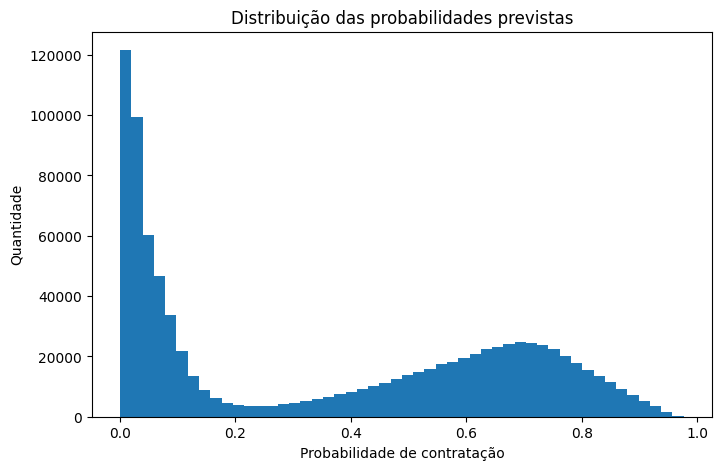

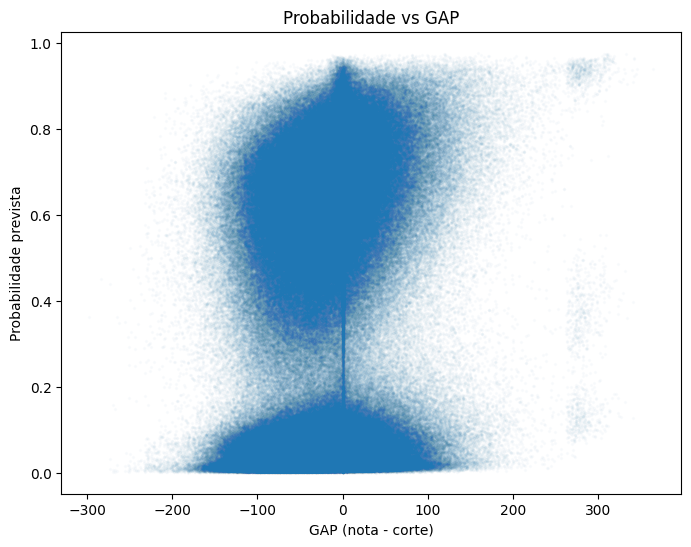

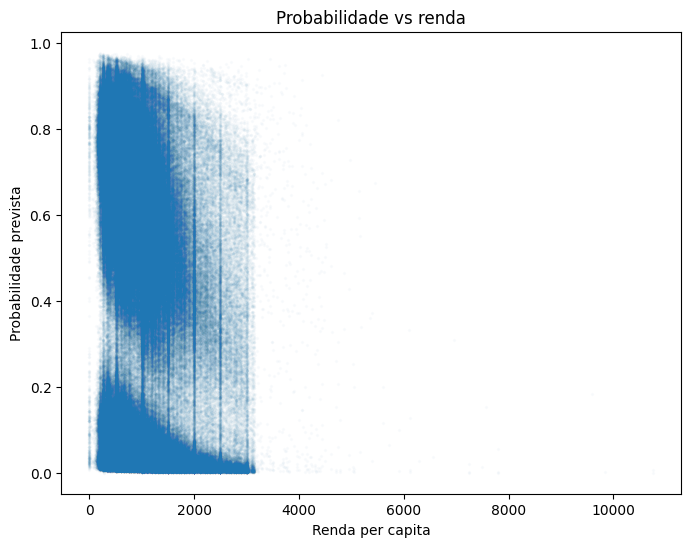

<ipython-input-1-13ba3156566e>:105: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabela = X.groupby(


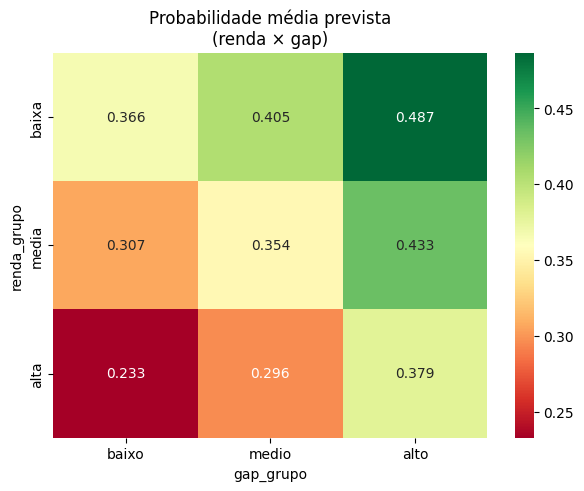

In [ ]:
# geracao de heatmap para os y_target binario mostrando a distriuicao das probabilidades em cada faixa segundo o modelo


def analisar_probabilidades_modelo(): #geral binario e eh dataset total

    import pandas as pd
    import joblib
    import matplotlib.pyplot as plt
    import seaborn as sns

    from constantes import (
        pasta_data_05_processed_analise_017_X_treino,
        pasta_modelo_analise_017
    )

    # -----------------------------
    # 1️⃣ Carregar dados
    # -----------------------------

    X = pd.read_parquet(str(pasta_data_05_processed_analise_017_X_treino))

    modelo = joblib.load(str(pasta_modelo_analise_017))

    print("Registros carregados:", len(X))

    # -----------------------------
    # 2️⃣ Probabilidade prevista
    # -----------------------------

    probs = modelo.predict_proba(X)[:,1]

    X["probabilidade_contratacao"] = probs

    # -----------------------------
    # 3️⃣ Distribuição das probabilidades
    # -----------------------------

    plt.figure(figsize=(8,5))

    plt.hist(probs, bins=50)

    plt.title("Distribuição das probabilidades previstas")
    plt.xlabel("Probabilidade de contratação")
    plt.ylabel("Quantidade")

    plt.show()

    # -----------------------------
    # 4️⃣ Probabilidade vs GAP
    # -----------------------------

    plt.figure(figsize=(8,6))

    plt.scatter(
        X["gap"],
        probs,
        alpha=0.02,
        s=2
    )

    plt.xlabel("GAP (nota - corte)")
    plt.ylabel("Probabilidade prevista")
    plt.title("Probabilidade vs GAP")

    plt.show()

    # -----------------------------
    # 5️⃣ Probabilidade vs renda
    # -----------------------------

    plt.figure(figsize=(8,6))

    plt.scatter(
        X["renda_per_capita"],
        probs,
        alpha=0.02,
        s=2
    )

    plt.xlabel("Renda per capita")
    plt.ylabel("Probabilidade prevista")
    plt.title("Probabilidade vs renda")

    plt.show()

    # -----------------------------
    # 6️⃣ Heatmap renda × gap
    # -----------------------------

    # discretizar renda
    X["renda_grupo"] = pd.qcut(
        X["renda_per_capita"],
        q=3,
        labels=["baixa","media","alta"]
    )

    # discretizar gap
    X["gap_grupo"] = pd.qcut(
        X["gap"],
        q=3,
        labels=["baixo","medio","alto"]
    )

    tabela = X.groupby(
        ["renda_grupo","gap_grupo"]
    )["probabilidade_contratacao"].mean().unstack()

    plt.figure(figsize=(7,5))

    sns.heatmap(
        tabela,
        annot=True,
        fmt=".3f",
        cmap="RdYlGn"
    )

    plt.title("Probabilidade média prevista\n(renda × gap)")

    plt.show()

    return X

df_resultado = analisar_probabilidades_modelo()

# import seaborn as sns

# sns.regplot(
#     x="gap",
#     y="probabilidade_contratacao",
#     data=df_resultado,
#     logistic=True,
#     scatter_kws={"alpha":0.01}
# )

Registros carregados: 23745


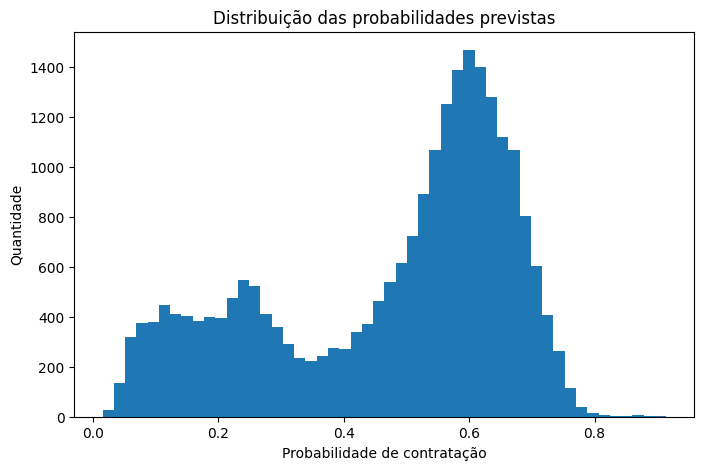

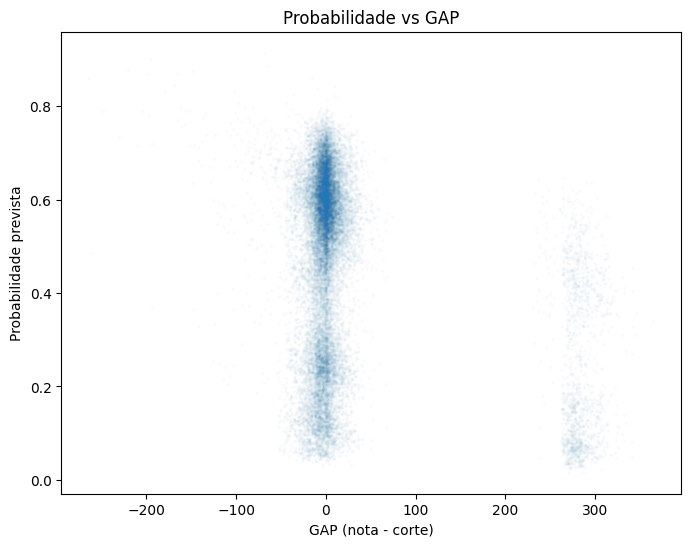

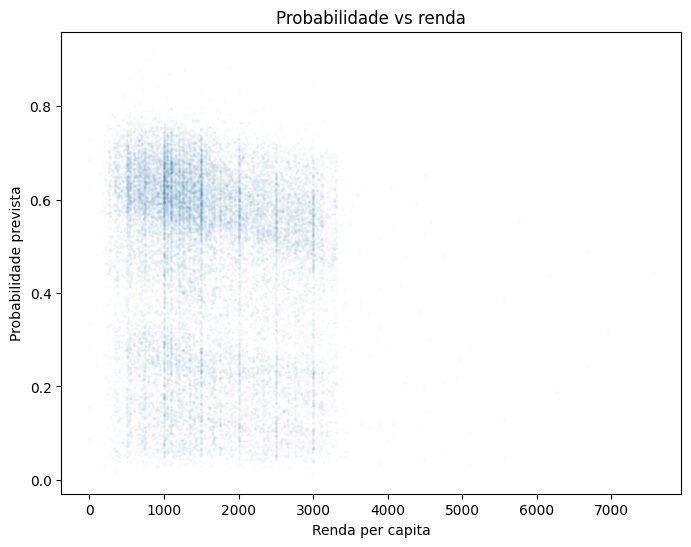

<ipython-input-2-d8e5a847da1c>:102: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabela = X.groupby(


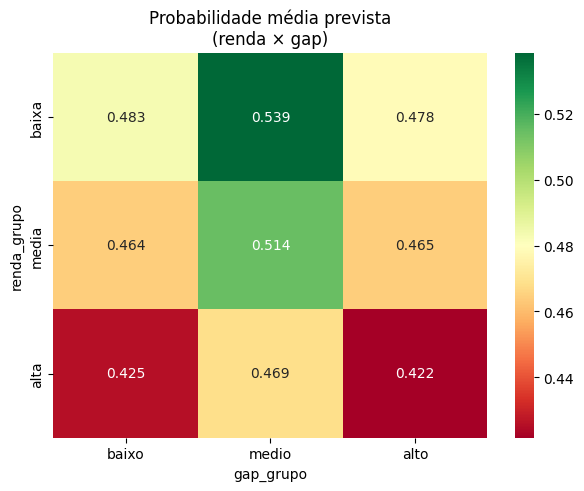

In [ ]:
def analisar_probabilidades_modelo(): # # apenas medicina binario e dataset total

    import pandas as pd
    import joblib
    import matplotlib.pyplot as plt
    import seaborn as sns

    from constantes import (
        pasta_data_05_processed_analise_015_X_treino,
        pasta_modelo_analise_015
    )

    # -----------------------------
    # 1️⃣ Carregar dados
    # -----------------------------

    X = pd.read_parquet(str(pasta_data_05_processed_analise_015_X_treino))

    modelo = joblib.load(str(pasta_modelo_analise_015))

    print("Registros carregados:", len(X))

    # -----------------------------
    # 2️⃣ Probabilidade prevista
    # -----------------------------

    probs = modelo.predict_proba(X)[:,1]

    X["probabilidade_contratacao"] = probs

    # -----------------------------
    # 3️⃣ Distribuição das probabilidades
    # -----------------------------

    plt.figure(figsize=(8,5))

    plt.hist(probs, bins=50)

    plt.title("Distribuição das probabilidades previstas")
    plt.xlabel("Probabilidade de contratação")
    plt.ylabel("Quantidade")

    plt.show()

    # -----------------------------
    # 4️⃣ Probabilidade vs GAP
    # -----------------------------

    plt.figure(figsize=(8,6))

    plt.scatter(
        X["gap"],
        probs,
        alpha=0.02,
        s=2
    )

    plt.xlabel("GAP (nota - corte)")
    plt.ylabel("Probabilidade prevista")
    plt.title("Probabilidade vs GAP")

    plt.show()

    # -----------------------------
    # 5️⃣ Probabilidade vs renda
    # -----------------------------

    plt.figure(figsize=(8,6))

    plt.scatter(
        X["renda_per_capita"],
        probs,
        alpha=0.02,
        s=2
    )

    plt.xlabel("Renda per capita")
    plt.ylabel("Probabilidade prevista")
    plt.title("Probabilidade vs renda")

    plt.show()

    # -----------------------------
    # 6️⃣ Heatmap renda × gap
    # -----------------------------

    # discretizar renda
    X["renda_grupo"] = pd.qcut(
        X["renda_per_capita"],
        q=3,
        labels=["baixa","media","alta"]
    )

    # discretizar gap
    X["gap_grupo"] = pd.qcut(
        X["gap"],
        q=3,
        labels=["baixo","medio","alto"]
    )

    tabela = X.groupby(
        ["renda_grupo","gap_grupo"]
    )["probabilidade_contratacao"].mean().unstack()

    plt.figure(figsize=(7,5))

    sns.heatmap(
        tabela,
        annot=True,
        fmt=".3f",
        cmap="RdYlGn"
    )

    plt.title("Probabilidade média prevista\n(renda × gap)")

    plt.show()

    return X

df_resultado = analisar_probabilidades_modelo()

# import seaborn as sns

# sns.regplot(
#     x="gap",
#     y="probabilidade_contratacao",
#     data=df_resultado,
#     logistic=True,
#     scatter_kws={"alpha":0.01}
# )